# 03 · Stationary univariate analysis and information expansion

The Kamp at Zwettl project is a nine-case Bayesian GEV study. The 1951–2005
record includes the 2002 flood; temporal expansion adds historical intervals and
a perception window. Causal information is an external quantile prior, not a flood.
Restart Kernel and Run All constructs every model from raw observations and runs MCMC.
The parallel API example in BestFit Verification is ViglioneEtAlTests.cs; its
Jeffreys and point-estimator settings differ from this saved app example.

In [2]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "runtime-lock.json").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from time import perf_counter
from math import log, expm1, isclose
import pandas as pd
from IPython.display import display
from bestfit_examples.runtime import load_bestfit
from bestfit_examples.raw import load_raw
from bestfit_examples.fresh import plot_context, plots, show, record_run
runtime = load_bestfit()
print(runtime)
from System import Array, Double, DateTime
from System.Collections.Generic import List
from Numerics.Data import ProbabilityOrdinates
from Numerics.Distributions import Normal, UnivariateDistributionType
from RMC.BestFit.Models import (DataFrame, ExactData, ExactSeries, IntervalData,
                                ThresholdData, QuantilePrior, UnivariateDistribution)
from RMC.BestFit.Analyses import UnivariateAnalysis
from RMC.BestFit.Estimation import BayesianAnalysis

{'schemaVersion': 1, 'sourceCommit': 'db5807d6e3a85606797cda79542f2d51a80a57a6', 'numericsVersion': '2.2.0.0', 'bestFitVersion': '2.0.0.0', 'targetFramework': '.NETCoreApp,Version=v10.0', 'fileHashes': {'RMC.BestFit.dll': '8714d7e4e9d738e99e45c36d5581ce759e8fd535361b7a141d9647a9a5eac8dd', 'Numerics.dll': '364d2296a6024643a8bf0f60d1eaa8f5be5511563dea0b5d572074e45c27ea48'}}


## Original observations and nine alternatives

Each temporal alternative uses its own input series with interval floods and
threshold evidence. The causal alternatives retain the systematic series and add
a prior to the 0.2% annual-exceedance quantile.

In [3]:
raw = load_raw("viglione-et-al-2013")
input_names = ["Systematic (1951-2001)", "Systematic (1951-2005)",
               "Systematic (1951-2001) + Temporal Expansion",
               "Systematic (1951-2005) + Temporal Expansion"]
case_specs = [
    ("MCMC - Systematic (1951-2001)", input_names[0], "none", "PosteriorMean"),
    ("MCMC - Systematic (1951-2005)", input_names[1], "none", "PosteriorMode"),
    ("MCMC - Systematic (1951-2001) + Temporal", input_names[2], "none", "PosteriorMean"),
    ("MCMC - Systematic (1951-2005) + Temporal", input_names[3], "none", "PosteriorMean"),
    ("MCMC - Systematic (1951-2001) + Causal", input_names[0], "causal", "PosteriorMean"),
    ("MCMC - Systematic (1951-2005) + Causal", input_names[1], "causal", "PosteriorMean"),
    ("MCMC - Systematic (1951-2001) + Temporal + Causal", input_names[2], "causal", "PosteriorMean"),
    ("MCMC - Systematic (1951-2005) + Temporal + Causal", input_names[3], "causal", "PosteriorMean"),
    ("MCMC - Systematic (1951-2001) + 3 Quantile Priors", input_names[0], "three", "PosteriorMean"),
]
display(pd.DataFrame(raw["inputs"][input_names[0]]["series"]["ExactSeries"]).head())
print(raw["source"])

,DateTime,Index,IsLowOutlier,Value
0,0001-01-01T00:00:00.0000000,1951,False,135
1,0001-01-01T00:00:00.0000000,1952,False,52
2,0001-01-01T00:00:00.0000000,1953,False,45
3,0001-01-01T00:00:00.0000000,1954,False,95
4,0001-01-01T00:00:00.0000000,1955,False,54


{'bytes': 14090240, 'relative_path': 'examples/4-univariate-distribution-analysis/1-univariate-analysis/1-information-expansion/viglione-et-al-2013.bestfit', 'repository_commit': '3fa55a0f75bbd583e2fb7fce42180faa376f007c', 'sha256': '6f6f984f8d0357d490ffde9d394601ae77324a0f293a84a3993afaf7e9762e86'}


## Construct the four evidence frames

A threshold's NumberAbove counts additional recorded exceedances. It does not
duplicate the explicitly entered interval events.

In [4]:
frames = {}
for input_name in input_names:
    observed = raw["inputs"][input_name]
    frame = DataFrame()
    frame.ExactSeries = ExactSeries()
    for row in observed["series"]["ExactSeries"]:
        point = ExactData(DateTime.Parse(row["DateTime"]), float(row["Value"]))
        point.Index = int(row["Index"])
        point.IsLowOutlier = row.get("IsLowOutlier", "False") == "True"
        frame.ExactSeries.Add(point)
    for row in observed["series"]["IntervalSeries"]:
        frame.IntervalSeries.Add(IntervalData(int(row["Index"]), float(row["LowerValue"]),
                                             float(row["Value"]), float(row["UpperValue"])))
    for row in observed["series"]["ThresholdSeries"]:
        threshold = ThresholdData(int(row["StartIndex"]), int(row["EndIndex"]), float(row["Value"]))
        threshold.NumberAbove = int(row["NumberAbove"])
        frame.ThresholdSeries.Add(threshold)
    frame.PlottingParameter = float(observed["attributes"]["PlottingParameter"])
    assert frame.Lambda == 1.0
    frame.CalculatePlottingPositions()
    frames[input_name] = frame
display(pd.DataFrame([{"Input": name, "Exact": f.ExactSeries.Count,
                       "Intervals": f.IntervalSeries.Count, "Thresholds": f.ThresholdSeries.Count}
                      for name, f in frames.items()]))
assert [frames[name].ExactSeries.Count for name in input_names] == [51, 55, 51, 55]
assert [frames[name].IntervalSeries.Count for name in input_names] == [0, 0, 3, 3]
assert [frames[name].ThresholdSeries.Count for name in input_names] == [0, 0, 1, 1]

,Input,Exact,Intervals,Thresholds
0,Systematic (1951-2001),51,0,0
1,Systematic (1951-2005),55,0,0
2,Systematic (1951-2001) + Temporal Expansion,51,3,1
3,Systematic (1951-2005) + Temporal Expansion,55,3,1


## Configure the GEV models and run the saved MCMC design

All nine saved app models use Jeffreys' scale prior. The published-result
Verification tests turn it off, so their parameter tolerances are not direct
acceptance tolerances for these reruns. Fitted parameters below come from MCMC.

In [5]:
aep = [1e-6, 2e-6, 5e-6, 1e-5, 2e-5, 5e-5, .0001, .0002, .0005,
       .001, .002, .005, .01, .02, .05, .1, .2, .3, .5, .7, .8, .9, .95, .98, .99]
analyses, models, timings = {}, {}, {}
for name, input_name, prior_kind, estimator in case_specs:
    model = UnivariateDistribution(frames[input_name], UnivariateDistributionType.GeneralizedExtremeValue)
    model.UseDefaultFlatPriors = True
    model.UseJeffreysRuleForScale = True
    if prior_kind == "causal":
        model.EnableQuantilePriors = True
        model.UseSingleQuantile = True
        priors = List[QuantilePrior]()
        priors.Add(QuantilePrior(.002, Normal(480., 80.)))
        model.QuantilePriors = priors
    elif prior_kind == "three":
        model.EnableQuantilePriors = True
        model.UseSingleQuantile = False
        priors = List[QuantilePrior]()
        priors.Add(QuantilePrior(.1, Normal(100., 20.)))
        priors.Add(QuantilePrior(.01, Normal(250., 40.)))
        priors.Add(QuantilePrior(.001, Normal(500., 60.)))
        model.QuantilePriors = priors
    analysis = UnivariateAnalysis(model)
    analysis.ProbabilityOrdinates = ProbabilityOrdinates(Array[Double](aep))
    bayes = analysis.BayesianAnalysis
    bayes.UseSimulationDefaults = True
    bayes.Type = BayesianAnalysis.SamplerType.DEMCzs
    bayes.NumberOfChains = 6
    bayes.ThinningInterval = 30
    bayes.WarmupIterations = 1200 if prior_kind == "three" else 1750
    bayes.Iterations = 2400 if prior_kind == "three" else 3500
    bayes.PRNGSeed = 12345
    bayes.UseAdvancedSimulationDefaults = True
    bayes.InitialIterations = 300
    bayes.Jump = .971630931303994
    bayes.JumpThreshold = .1
    bayes.SnookerThreshold = .1
    bayes.Noise = 1e-12
    bayes.Scale = 5.6644
    bayes.Beta = .05
    bayes.MaxTreeDepth = 10
    bayes.CredibleIntervalWidth = .95 if prior_kind == "three" else .9
    bayes.OutputLength = 10000
    bayes.PointEstimator = getattr(BayesianAnalysis.PointEstimateType, estimator)
    started = perf_counter()
    analysis.RunAsync(None).GetAwaiter().GetResult()
    timings[name] = perf_counter() - started
    analyses[name], models[name] = analysis, model
    record_run(name, analysis, timings[name], raw=raw, model=model)

MCMC - Systematic (1951-2001): completed in 2.14 s. Execution alone does not establish convergence or scientific acceptance.


MCMC - Systematic (1951-2005): completed in 1.14 s. Execution alone does not establish convergence or scientific acceptance.


MCMC - Systematic (1951-2001) + Temporal: completed in 1.21 s. Execution alone does not establish convergence or scientific acceptance.


MCMC - Systematic (1951-2005) + Temporal: completed in 1.22 s. Execution alone does not establish convergence or scientific acceptance.


MCMC - Systematic (1951-2001) + Causal: completed in 1.15 s. Execution alone does not establish convergence or scientific acceptance.


MCMC - Systematic (1951-2005) + Causal: completed in 1.14 s. Execution alone does not establish convergence or scientific acceptance.


MCMC - Systematic (1951-2001) + Temporal + Causal: completed in 1.23 s. Execution alone does not establish convergence or scientific acceptance.


MCMC - Systematic (1951-2005) + Temporal + Causal: completed in 1.41 s. Execution alone does not establish convergence or scientific acceptance.


MCMC - Systematic (1951-2001) + 3 Quantile Priors: completed in 1.73 s. Execution alone does not establish convergence or scientific acceptance.


## Compare fresh estimates and intervals

Read the selected point estimate and credible interval with each case's data
period and prior. Fit scores across changed evidence or priors are not a ranking.

In [6]:
rows = []
for name, input_name, prior_kind, estimator in case_specs:
    analysis = analyses[name]
    result = analysis.BayesianAnalysis.Results
    assert analysis.IsEstimated and result is not None
    rows.append({"Case": name, "Input": input_name, "Prior": prior_kind,
                 "Estimator": estimator, "MAP parameters": list(result.MAP.Values),
                 "1% AEP parameter point estimate": float(analysis.AnalysisResults.ModeCurve[aep.index(.01)])})
display(pd.DataFrame(rows))
# Independent Hosking-parameterized GEV inverse CDF for the freshly selected
# parameter point estimate. This checks curve ordinates at common and rare AEPs.
for name, _, _, _ in case_specs:
    distribution = analyses[name].GetPointEstimateDistribution()
    xi, alpha, kappa = (float(distribution.Xi), float(distribution.Alpha),
                         float(distribution.Kappa))
    for probability in (.5, .01, .001):
        t = -log(1.0 - probability)
        expected = xi - alpha * log(t) if abs(kappa) < 1e-12 else (
            xi - alpha * expm1(kappa * log(t)) / kappa)
        actual = float(analyses[name].AnalysisResults.ModeCurve[aep.index(probability)])
        assert isclose(actual, expected, rel_tol=1e-10, abs_tol=1e-8)
diagnostics = []
for name, _, _, _ in case_specs:
    result = analyses[name].BayesianAnalysis.Results
    for i, parameter in enumerate(result.ParameterResults):
        stats = parameter.SummaryStatistics
        diagnostics.append({"Case": name, "Parameter": str(models[name].Parameters[i].DisplayName),
                            "R-hat": float(stats.Rhat), "ESS": float(stats.ESS)})
display(pd.DataFrame(diagnostics))

,Case,Input,Prior,Estimator,MAP parameters,1% AEP parameter point estimate
0,MCMC - Systematic (1951-2001),Systematic (1951-2001),none,PosteriorMean,"[42.83818057832287, 19.822705886785766, -0.101...",172.725929
1,MCMC - Systematic (1951-2005),Systematic (1951-2005),none,PosteriorMode,"[41.360422653501416, 20.434641952964423, -0.31...",251.850396
2,MCMC - Systematic (1951-2001) + Temporal,Systematic (1951-2001) + Temporal Expansion,none,PosteriorMean,"[43.029283466631455, 21.427109989223368, -0.22...",221.099620
3,MCMC - Systematic (1951-2005) + Temporal,Systematic (1951-2005) + Temporal Expansion,none,PosteriorMean,"[42.31207815481268, 20.986185897632733, -0.288...",249.897983
4,MCMC - Systematic (1951-2001) + Causal,Systematic (1951-2001),causal,PosteriorMean,"[41.548609509399654, 20.719599648798177, -0.31...",246.933641
5,MCMC - Systematic (1951-2005) + Causal,Systematic (1951-2005),causal,PosteriorMean,"[41.24460290551673, 20.5926673085153, -0.33932...",263.650870
6,MCMC - Systematic (1951-2001) + Temporal + Causal,Systematic (1951-2001) + Temporal Expansion,causal,PosteriorMean,"[42.657361367117716, 21.55473686625308, -0.290...",250.039320
7,MCMC - Systematic (1951-2005) + Temporal + Causal,Systematic (1951-2005) + Temporal Expansion,causal,PosteriorMean,"[42.348425602522674, 21.30928101766086, -0.313...",260.861157
8,MCMC - Systematic (1951-2001) + 3 Quantile Priors,Systematic (1951-2001),three,PosteriorMean,"[41.1892083162334, 19.783104484379255, -0.2864...",230.438761


,Case,Parameter,R-hat,ESS
0,MCMC - Systematic (1951-2001),Location (ξ),1.000057,9658.810044
1,MCMC - Systematic (1951-2001),Scale (α),1.000154,9428.776362
2,MCMC - Systematic (1951-2001),Shape (κ),1.000048,9732.266700
3,MCMC - Systematic (1951-2005),Location (ξ),1.000267,9936.496030
4,MCMC - Systematic (1951-2005),Scale (α),1.000363,9860.714885
5,MCMC - Systematic (1951-2005),Shape (κ),1.000039,9057.136152
6,MCMC - Systematic (1951-2001) + Temporal,Location (ξ),1.000366,9453.214411
7,MCMC - Systematic (1951-2001) + Temporal,Scale (α),0.999979,9230.039377
8,MCMC - Systematic (1951-2001) + Temporal,Shape (κ),1.000154,9749.173573
9,MCMC - Systematic (1951-2005) + Temporal,Location (ξ),1.000364,9873.163702


## View the computed frequency and posterior diagnostics

Plot adapters read the analyses above. A completed chain is not itself
convergence or scientific acceptance; examine the diagnostic views before
interpreting tail differences.

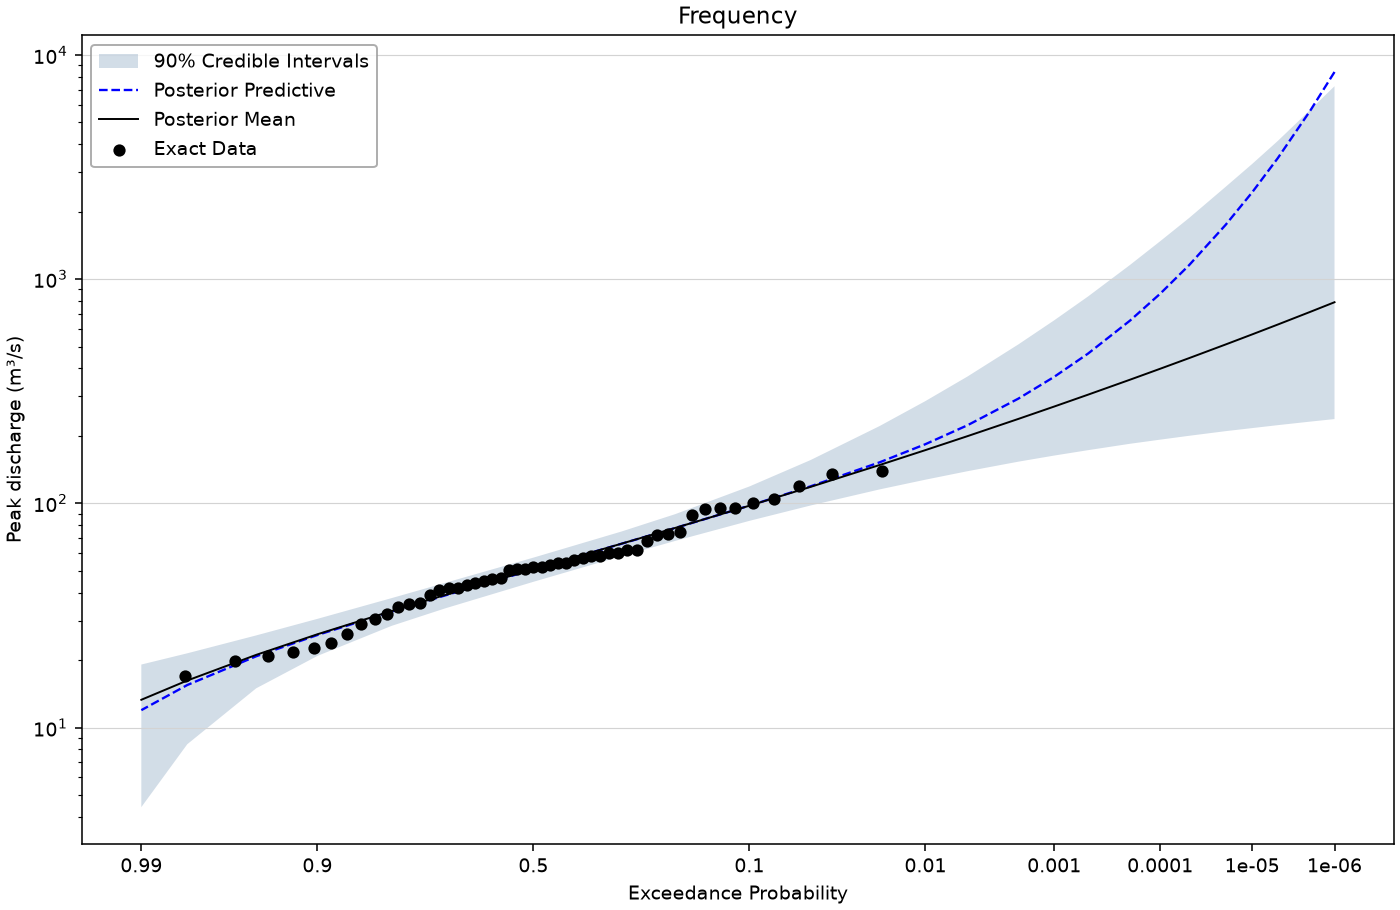

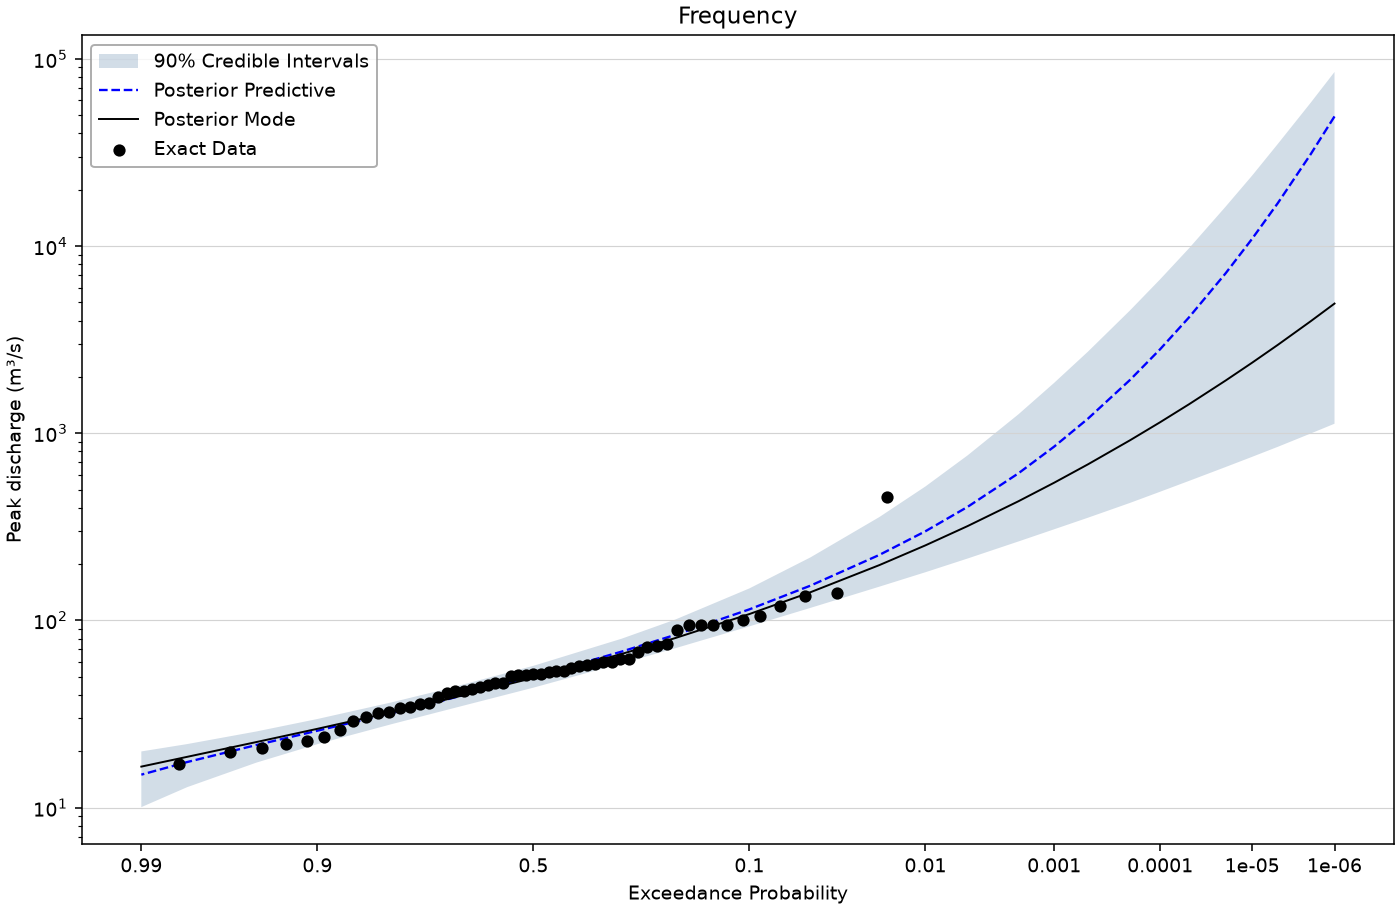

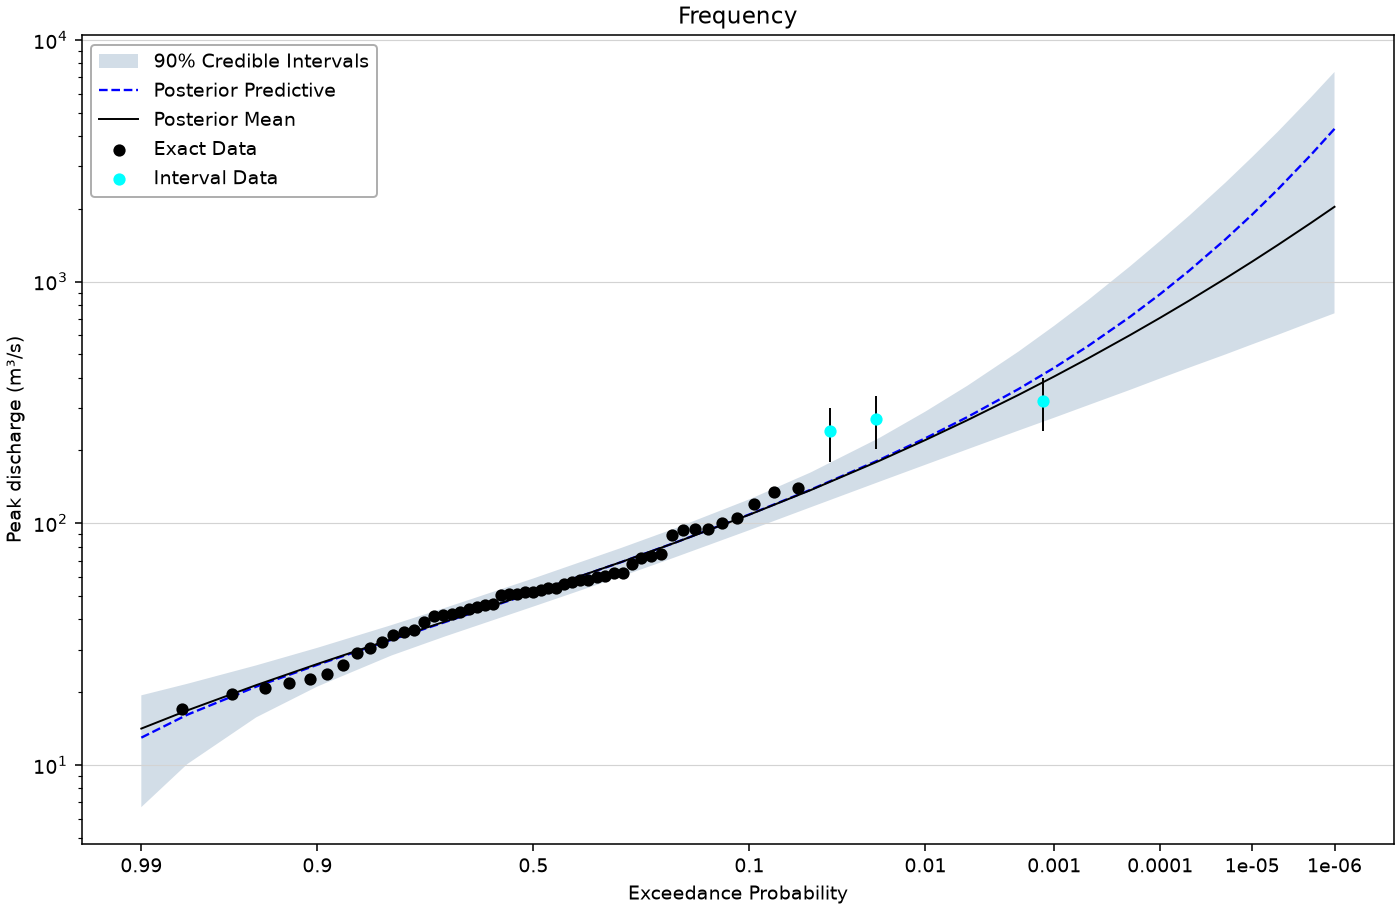

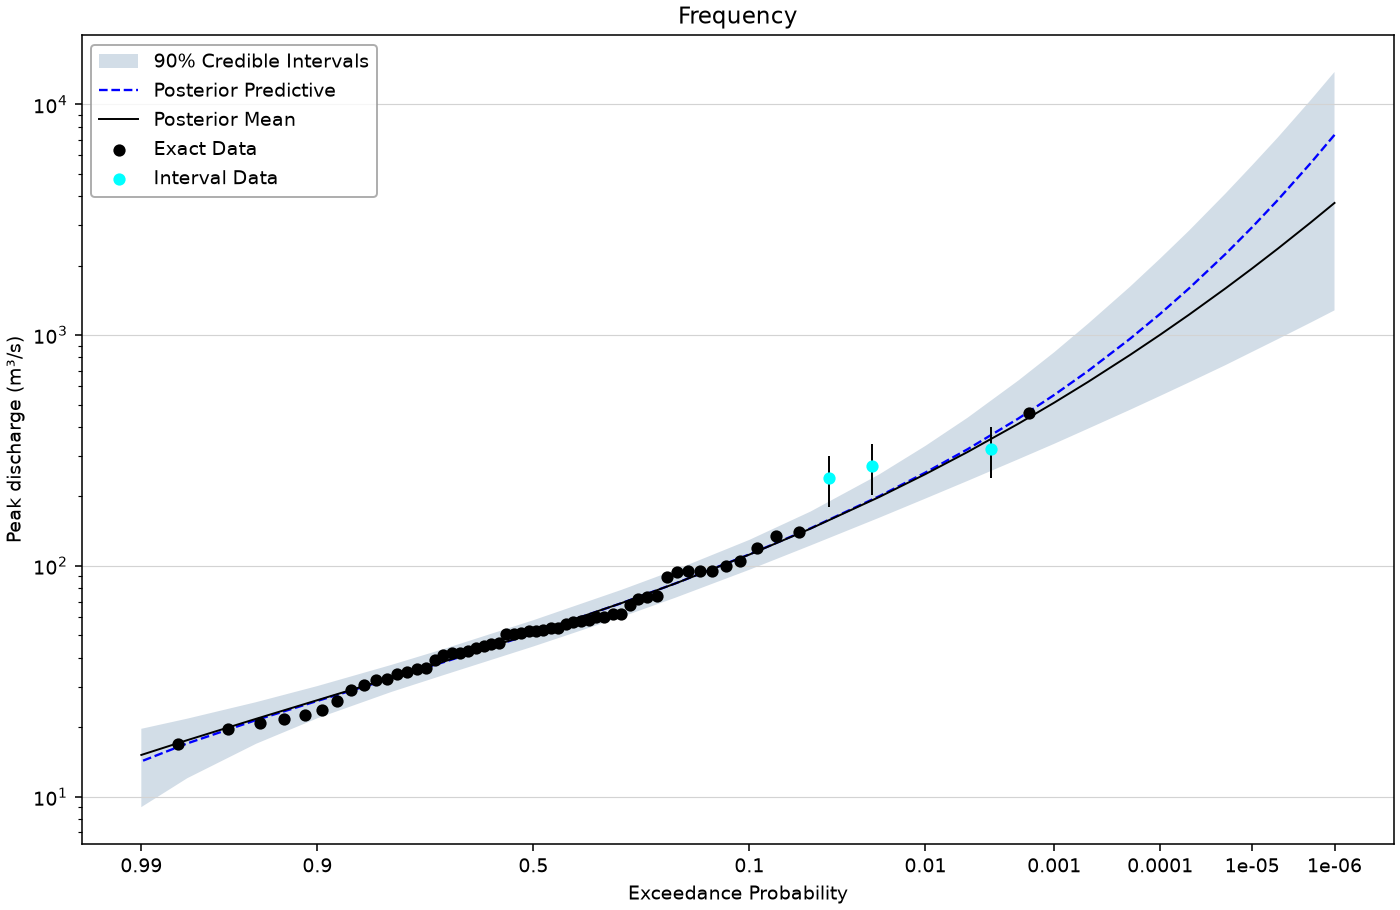

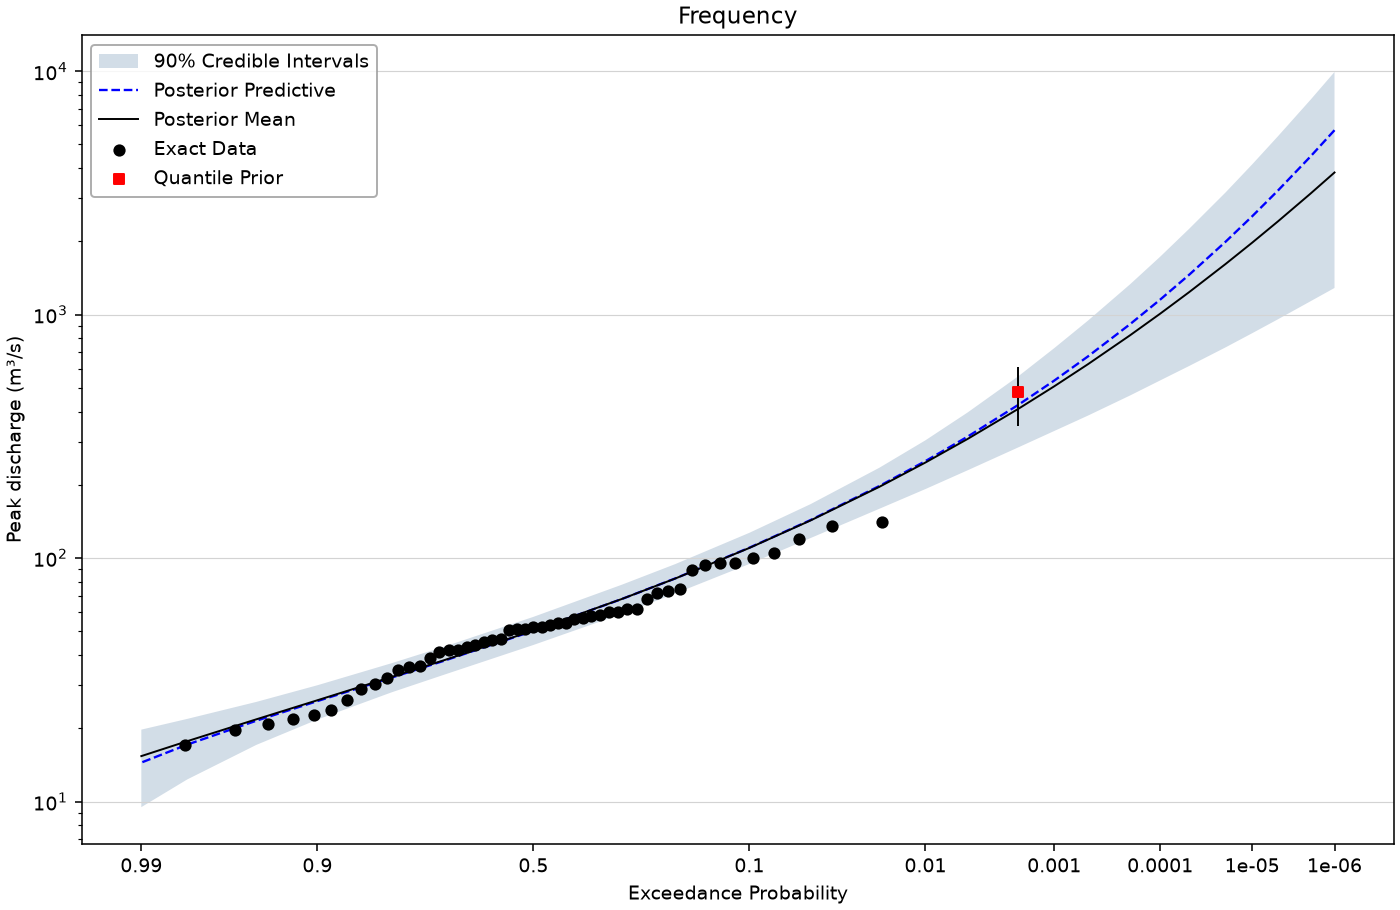

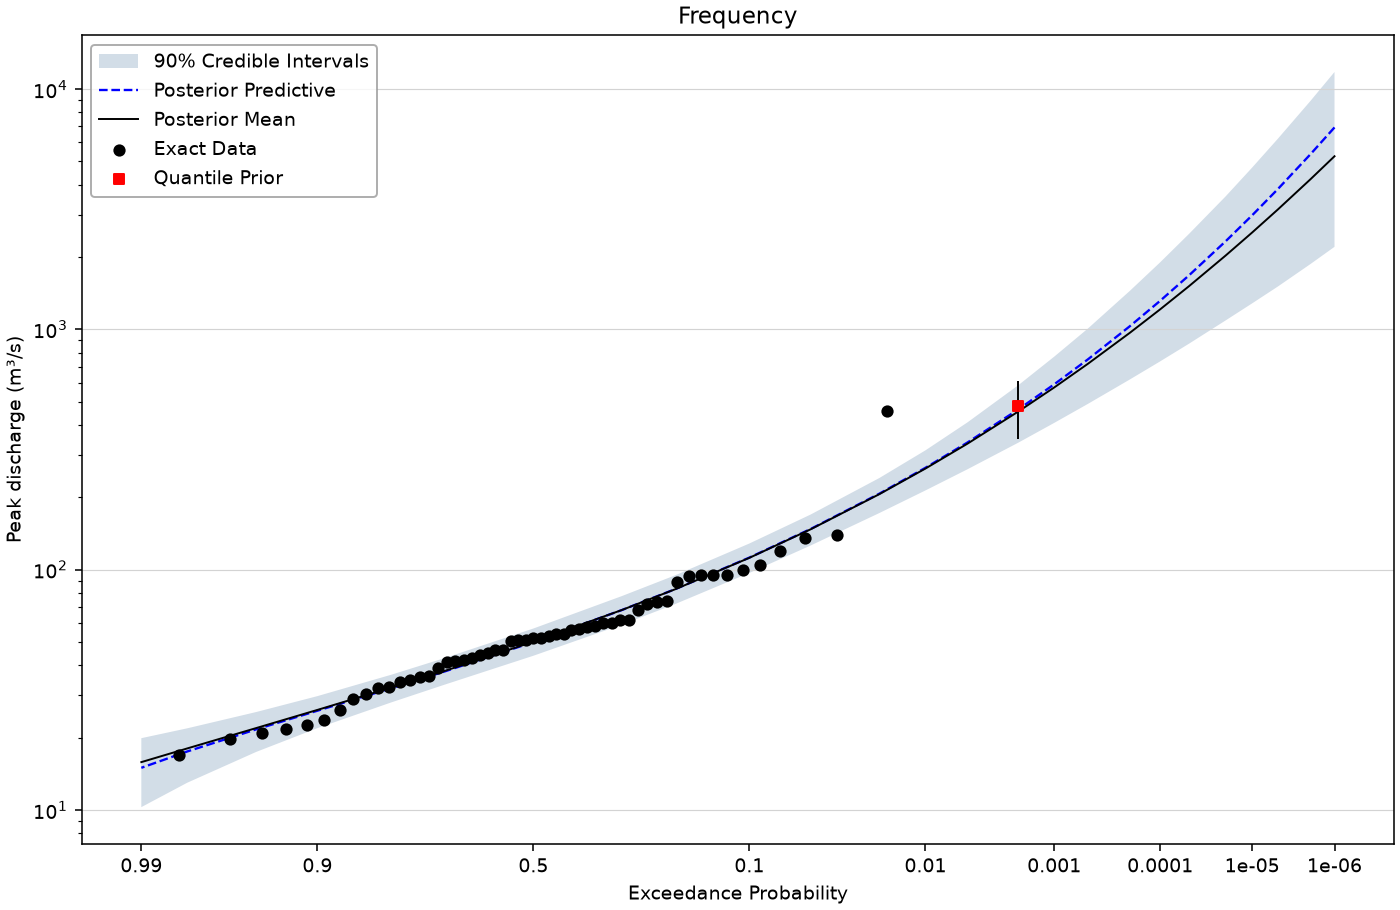

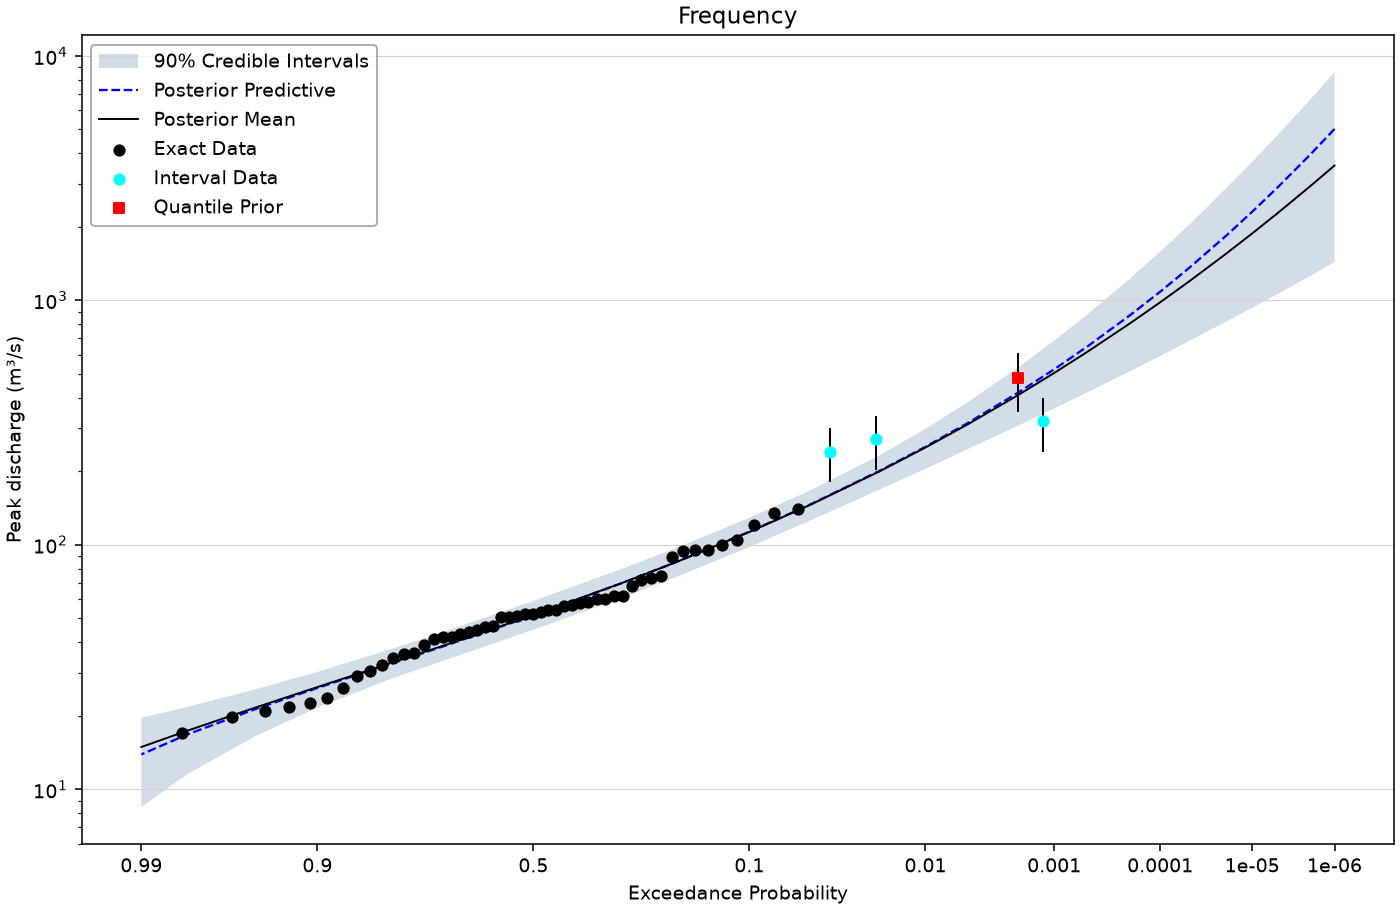

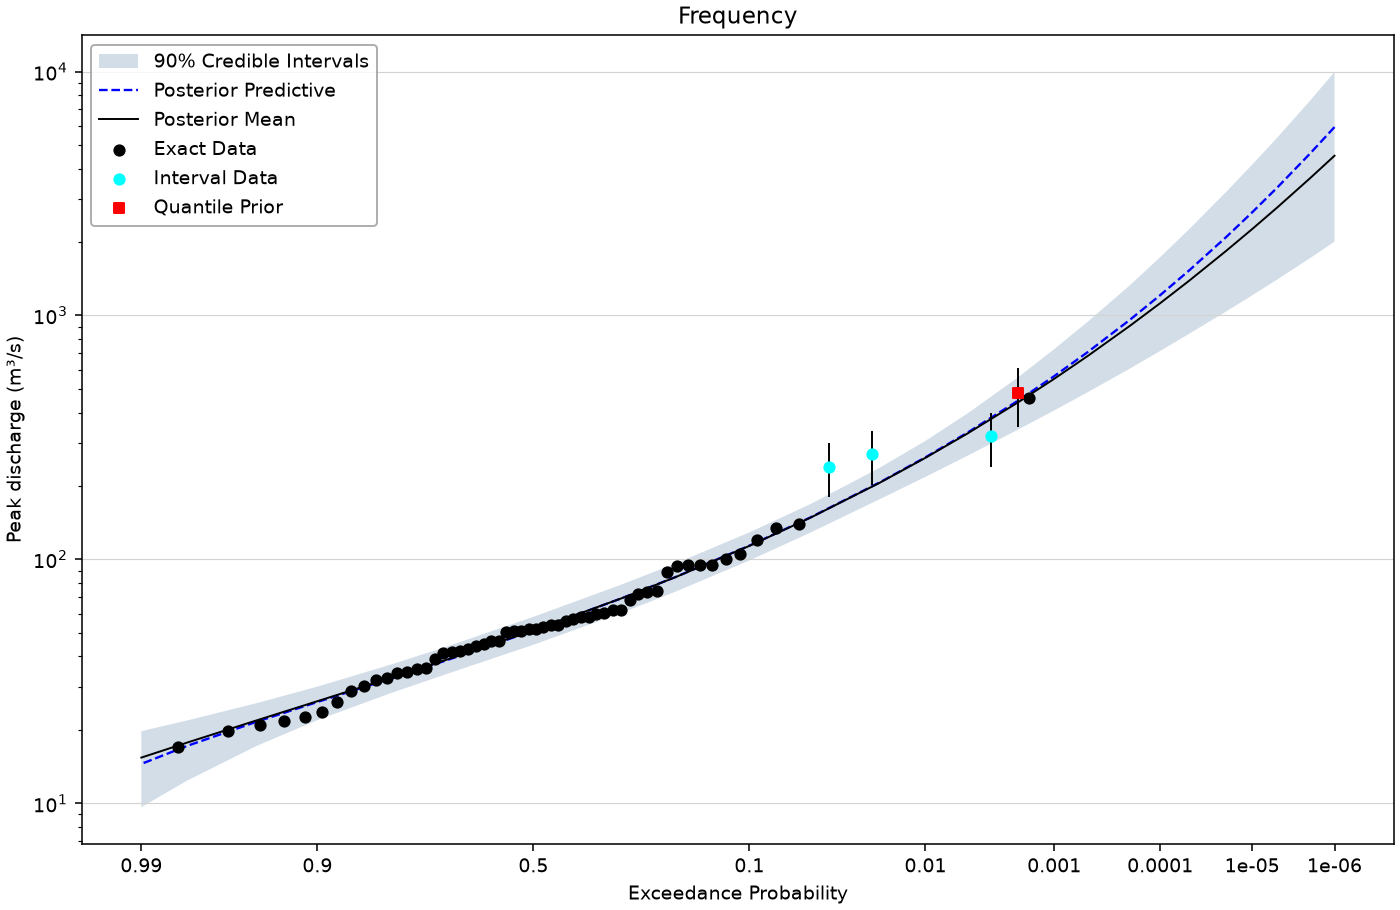

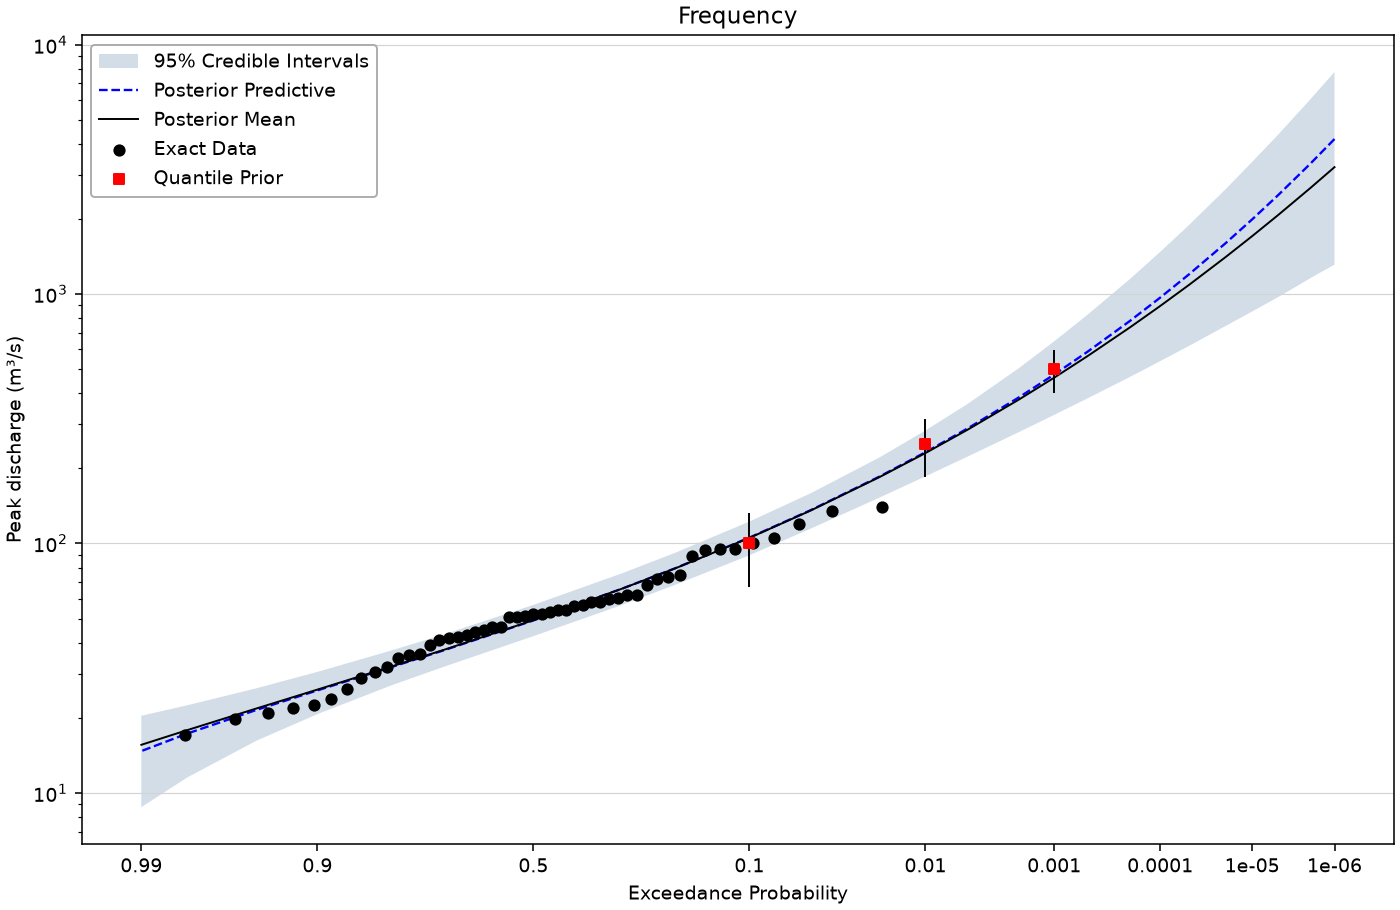

Diagnostic views: ['diagnostic_histogram', 'diagnostic_kde', 'diagnostic_acf', 'diagnostic_pair_heatmap', 'diagnostic_trace', 'diagnostic_mean_log_likelihood', 'diagnostic_influence']


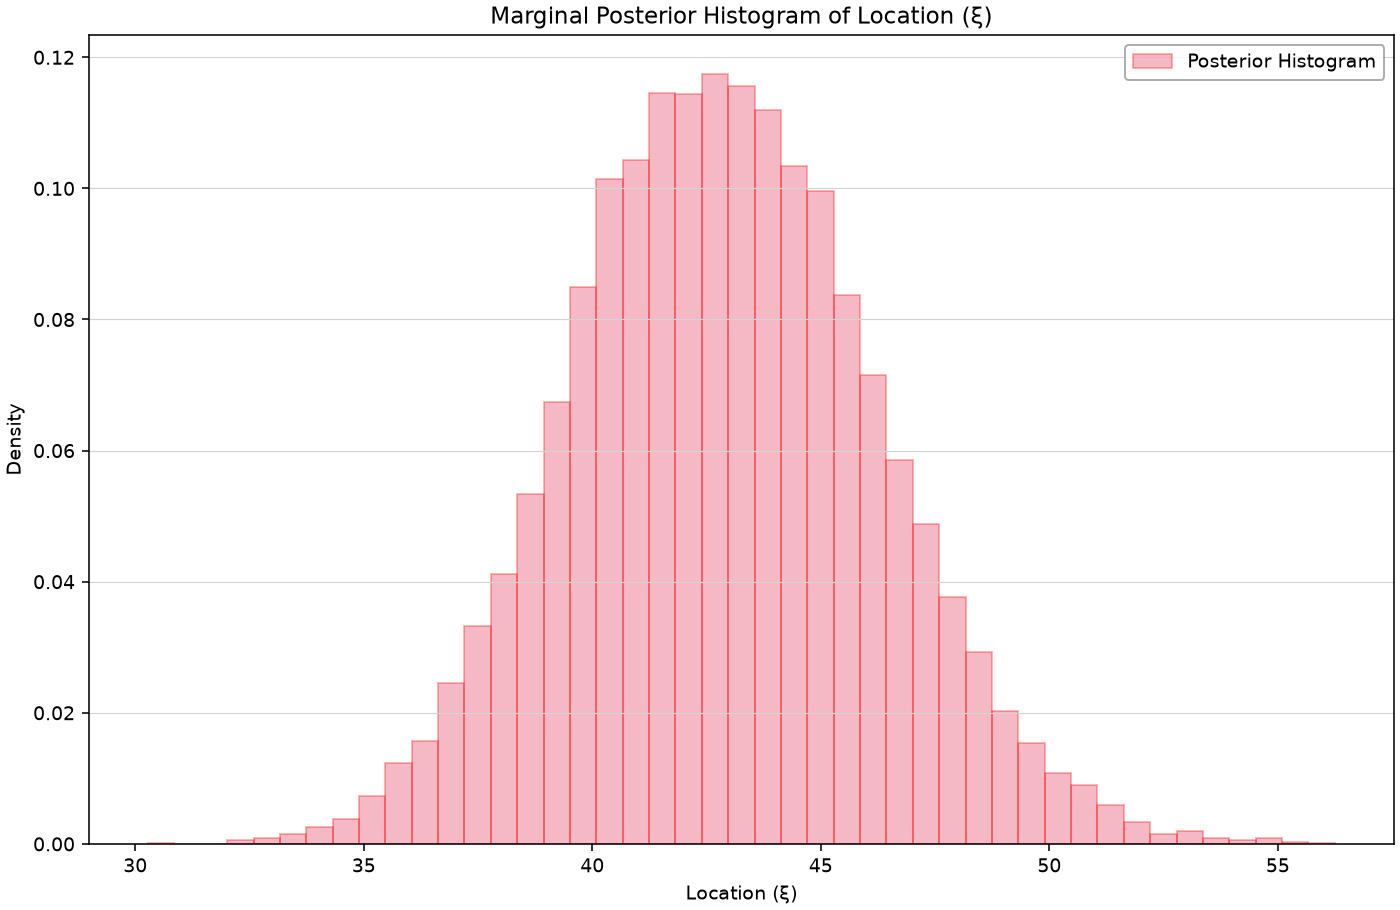

In [7]:
specs = {}
for name, input_name, _, _ in case_specs:
    context = plot_context(analyses[name], models[name], name=name, raw=raw,
                           frame=frames[input_name], metadata=raw["inputs"][input_name]["metadata"],
                           unitLabel="Peak discharge (m³/s)")
    specs[name] = plots(context, diagnostics=True)
    show(specs[name]["frequency"])
diagnostic_keys = [key for key in specs[case_specs[0][0]] if key.startswith("diagnostic_")]
print("Diagnostic views:", diagnostic_keys)
if diagnostic_keys:
    show(specs[case_specs[0][0]][diagnostic_keys[0]])

**Adapt this example:** enter your exact, interval and threshold evidence;
state quantile-prior sources independently; then fit a newly constructed GEV.
Source: Viglione et al. (2013), DOI 10.1029/2011WR010782.